# Project 2: Clustering of Health News Tweets
#### Group 1: Eli Westrick, Jacob Anderson

## Feature Extraction

We first preprocess the CNN health news data, which involved removing URLs, removing tweet symbols like @'s and #'s, and eliminating extra whitespace and punctuation. This step also revealed duplicate tweets within the dataset that were being repurposed and posted again days apart, linked to the same articles. We removed these duplicates to avoid capturing identical similarity structures in our final clustering. Another preprocessing step we carried out was the conversion to Term Frequency–Inverse Document Frequency (TF-IDF) vectors, which weight the raw counts of each term relative to their frequency across the corpus.

The weighting under the SciPy implementation is defined for each term t in a given document ($i.e.$ tweet) d as $ TF\text{-}IDF(t, d) = TF(t, d) \cdot IDF(t) $, where $ TF(t, d) = \text{count of } t \text{ in document } d $, $ IDF(t) = \log \left( \frac{1 + N}{1 + df(t)} \right) + 1 $, and $ df(t) $ refers to the number of tweets containing t over the dataset. This implementation also includes an L2 normalization step to impose unit length over all vectorizations, $ \mathbf{v}_d \leftarrow \frac{\mathbf{v}_d}{\|\mathbf{v}_d\|} $.

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy.sparse import load_npz, save_npz
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
 
os.makedirs("../figures", exist_ok=True)

In [2]:
#loading data
input_file = "../data/cnnhealth.txt"   

with open(input_file, "r", encoding="utf-8") as f:
    lines = [re.sub(r"\|\s+", " ", line) for line in f]

df = pd.read_csv(pd.io.common.StringIO("".join(lines)), sep="|", header=None)
df.columns = ["id", "timestamp", "text"]

#remove duplicates
df["urls"] = df["text"].apply(lambda x: re.findall(r"http\S+|www\S+", str(x)))

# keep only the first tweet per unique URL
url_to_keep = {}
indices_to_drop = set()

for idx, url_list in enumerate(df["urls"]):
    for url in url_list:
        if url in url_to_keep:
            indices_to_drop.add(idx)  # duplicate URL, mark for removal
        else:
            url_to_keep[url] = idx    # first occurrence

df = df.drop(index=list(indices_to_drop)).reset_index(drop=True)

# remove temporary 'urls' column
df = df.drop(columns=["urls"])

print(f"Removed {len(indices_to_drop)} tweets due to duplicate URLs. Remaining: {len(df)}")
#cleaning

def clean_text(text):
    text = str(text)
    
    # remove leading 'RT ' at the beginning
    text = re.sub(r"^\s*rt\s+", "", text, flags=re.IGNORECASE)
    
    # remove all other instances of ' rt ' (with spaces around)
    text = re.sub(r"\s+rt\s+", " ", text, flags=re.IGNORECASE)
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    
    # remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # convert to lowercase
    text = text.lower()
    
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["text"].apply(clean_text)
before = len(df)
df = df.drop_duplicates(subset="clean_text", keep="first").reset_index(drop=True)
after = len(df)

#taking care of the trailing via
df["clean_text_stripped"] = df["clean_text"].str.replace(r"\s+via(\s+@\w+)?$", "", regex=True)

#removing dupes based on the via
before_dupes = len(df)
df = df.drop_duplicates(subset="clean_text_stripped", keep="first").reset_index(drop=True)
after_dupes = len(df)

print(f"Removed {before_dupes - after_dupes} duplicate tweets due to trailing 'via'. Remaining: {after_dupes}")
df = df.drop(columns=["clean_text_stripped"])

#vectorization

USE_TFIDF = True   #set to false for raw counts

if USE_TFIDF:
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),   # unigrams + bigrams
        min_df=2              # ignore very rare words
    )
else:
    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )

X = vectorizer.fit_transform(df["clean_text"])

mask = (X.sum(axis=1) > 0).A1
X = X[mask]
df = df[mask].reset_index(drop=True)

# save outputs
save_npz("tweet_features.npz", X)
np.savetxt("tweet_features.txt", X.toarray(), fmt="%.6f")

df["clean_text"].to_csv("cleaned_tweets.txt", index=False, header=False)

#a few sanity checks
feature_names = vectorizer.get_feature_names_out()
row_sums = X.sum(axis=1)
num_docs, num_features = X.shape
avg_nonzero = X.nnz / num_docs

# sparsity
sparsity = 1 - (X.nnz / (num_docs * num_features))

Removed 288 tweets due to duplicate URLs. Remaining: 3769
Removed 3 duplicate tweets due to trailing 'via'. Remaining: 3718


The preprocessing step removed a total of 348 tweets from the original dataset. Among the different cleaning steps, 288 tweets sharing duplicate URLs with an earlier tweet were discarded, 48 tweets sharing identical text were taken out, 3 tweets that were otherwise exact text duplicates but referenced a specific person with an @ symbol were removed, and 9 tweets that produced zero length feature vectors following the TF-IDF vectorization were removed. This can occur after TF-IDF vectorization due to the removal of stopwords, the removal of very infrequent terms that appear in fewer than two documents in the corpus, and the filtering of any terms outside of the top 5000 most frequent terms in the corpus. In other words, tweets that use very uncommon language that would regardless be outlying in any clustering scheme were discarded as they are not of particular interest to the analysis.

### Feature Matrix Summary Statistics

In [3]:
# Raw count matrix to get true term token count
count_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
X_counts = count_vectorizer.fit_transform(df["clean_text"])
term_tokens = int(X_counts.sum())

print("Dataset Name: CNN Health Tweets")
print("#Documents:", num_docs)
print("#Term Tokens:", term_tokens)
print("#Unique Terms:", num_features)
print(f"Avg Term per Document: {avg_nonzero:.2f}")
print("Description: Tweets")

Dataset Name: CNN Health Tweets
#Documents: 3709
#Term Tokens: 25333
#Unique Terms: 4189
Avg Term per Document: 6.76
Description: Tweets


Our final dataset includes 3,709 tweets for clustering, of which 4,189 unique words are used 25,333 times over the corpus, averaging a usage of 6.76 terms per tweet.

## Proximity Measures
Cosine similarity and Jaccard similarity are used as proximity measures in the clustering analysis. These measures are used with a few primary limitations of the data representation in mind. First, this feature space is not amenable to distance measures like Euclidean distance that would shrink the relative distances between the documents and making comparison difficult at high dimensions. Likewise, the selected measures are not sensitive to the magnitude of the tweets vectors and will not conflate the additional length of a tweets with additional distance in the feature space that could otherwise separate two tweets that may be quite similar topically. Cosine similarity addresses the latter concern more directly by measuring the angle between the feature vectors, which is effectively invariant to the length of the tweets. It is also appropriate by this same construction for similarity in a high dimensional space. 

Secondly, the sparsity of the feature matrix is handled naturally by cosine similarity because it's construction does not penalize zero entries in the feature dimensions that have no usage in a given tweet, which makes it convenient for gauging proximity of even very dissimilar and very short tweets. This same sparsity also naturally motivates Jaccard as a proximity measure because it contrains the observed dimensions when measuring similarity to just the terms used by the given pair of tweets, focusing directly on the overlap that exists between them.

Regarding the representation model itself, bag-of-words does not preserve any notion of order of the terms within each tweet. Because cosine similarity and Jaccard similarity as measures are motivated by co-occurrence of terms, the similarity they represent in this space is consistent with the information that is actually being encoded in the feature vectors, which again by construction makes them naturally effective selections for this data. 

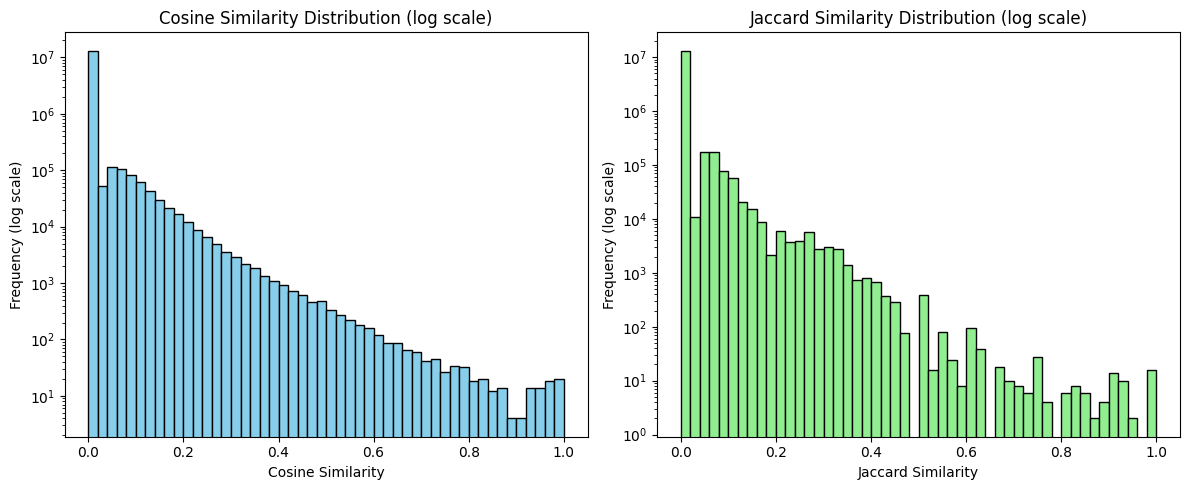

In [4]:
#cosine similarity
cos_sim = cosine_similarity(X)
np.savetxt("cosine_similarity.txt", cos_sim)

#jaccard similarity, binarize the matrix so it doesn't take a year to run
X_bin = (X > 0).astype(int)  # binarize
intersection = X_bin @ X_bin.T
row_sums = X_bin.sum(axis=1).A1
union = row_sums[:, None] + row_sums[None, :] - intersection.toarray()
jaccard_sim = intersection.toarray() / union
np.savetxt("jaccard_similarity.txt", jaccard_sim)

# Removes the 1.0 similarities along the diagonals
nondiagonal_mask = np.ones(cos_sim.shape, dtype=bool)
np.fill_diagonal(nondiagonal_mask, False)
cos_vals = cos_sim[nondiagonal_mask]
jac_vals = jaccard_sim[nondiagonal_mask]

#histograms with a log scale
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(cos_vals.flatten(), bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Cosine Similarity Distribution (log scale)")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency (log scale)")

plt.subplot(1,2,2)
plt.hist(jac_vals.flatten(), bins=50, color='lightgreen', edgecolor='black', log=True)
plt.title("Jaccard Similarity Distribution (log scale)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

The distributions both appear quite right-skewed as one would expect for such a high dimensional and sparse feature space. In the case of cosine similarity, the smooth decay from the left suggests that clustering on this measure as a heuristic may prove somewhat challenging because groupings of tweets by topical show very little variation in the similarity due to shared terms. However, the Jaccard measure, while similarly motivated by the occurrence of shared terms, shows irregular and non-monotonic patterns as the distribution decays from 0 to 1, potentially suggesting that there are small groupings of tweets sharing certain proportions of their vocabulary that are being detected by the measure. The Jaccard similarity due to its stricter requirement of term overlap to output a non-zero similarity has shown that within the tweets that do share terms, there is slight and detectable differentiations of tweets by the degree of their overlap. 

In a comparison of the two measures, both of them establish that the feature space is overwhelmingly sparse and justify the usage of these two measures for their prioritization of co-occurrence of terms in the feature space, with Jaccard being potentially quite favorable for this representation.

## Clustering Algorithms


### Spherical K-Means

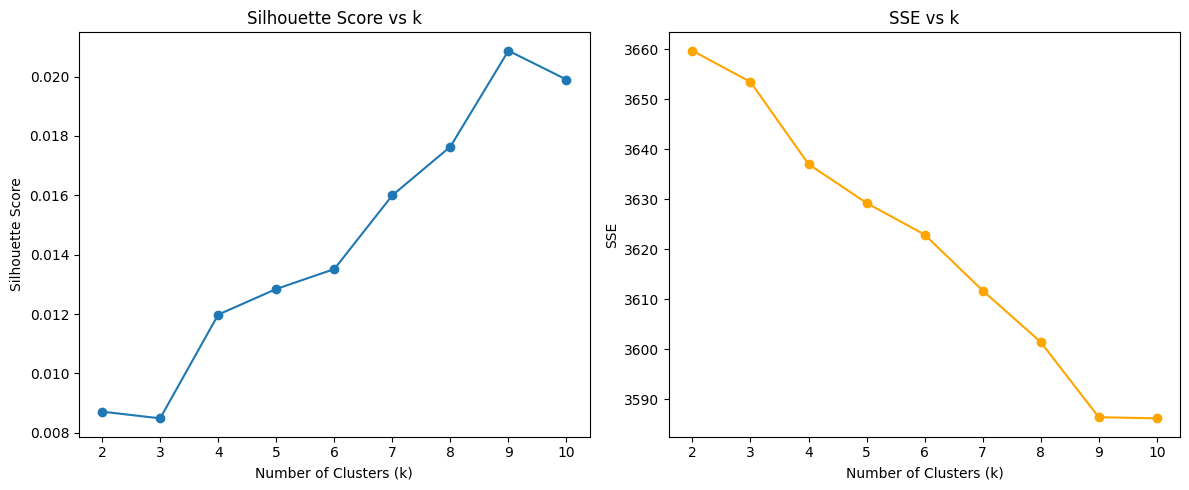

Optimal number of clusters based on silhouette score: 9
Cluster sizes:
Cluster 0: 2632 tweets
Cluster 1: 92 tweets
Cluster 2: 101 tweets
Cluster 3: 156 tweets
Cluster 4: 105 tweets
Cluster 5: 132 tweets
Cluster 6: 151 tweets
Cluster 7: 209 tweets
Cluster 8: 131 tweets


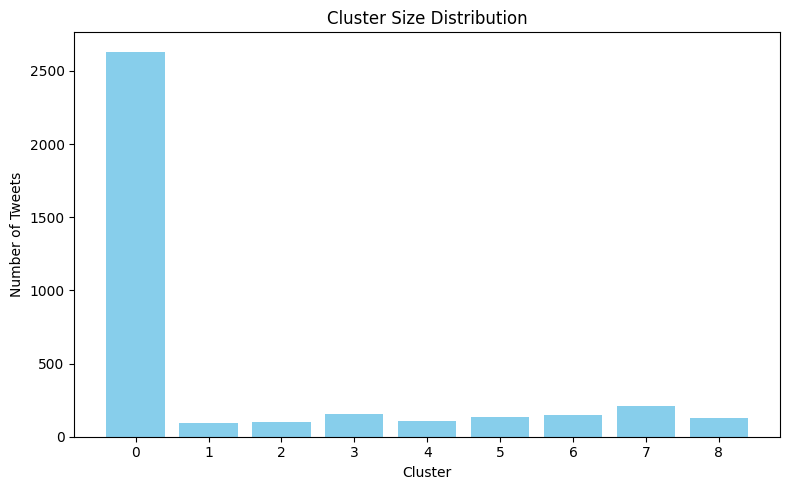


final metrics:
Silhouette Score: 0.0209
SSE (Cohesion): 3586.4181
BSS (Separation): 105.3929


In [5]:
warnings.filterwarnings("ignore")

#normalize to do spherical
X_normalized = normalize(X, norm='l2', axis=1)
X_reduced = TruncatedSVD(n_components=100, random_state=42).fit_transform(X_normalized)

#cosine similarity matrix
cos_sim_kmeans = cosine_similarity(X_reduced)
cos_dist_kmeans = 1 - cos_sim_kmeans

max_k = 10
sil_scores = []
SSE = []

for k in range(2, max_k+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels_tmp = kmeans.fit_predict(X_normalized)
    
    # silhouette (cosine metric works on sparse)
    score = silhouette_score(X_normalized, kmeans_labels_tmp, metric='cosine')
    sil_scores.append(score)
    
    # SSE for sparse matrix
    sse = 0
    for cluster_id in range(k):
        cluster_points = X_normalized[kmeans_labels_tmp == cluster_id]
        center = kmeans.cluster_centers_[cluster_id]
        sse += np.sum((cluster_points.toarray() - center)**2)
    SSE.append(sse)

#silhouette and sse based on cluster size
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(2, max_k+1), sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")

plt.subplot(1,2,2)
plt.plot(range(2, max_k+1), SSE, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.title("SSE vs k")

plt.tight_layout()
plt.savefig("../figures/kmeans_cluster_quality_metrics.png")
plt.show()

#pick the k with highest silhouette score
kmeans_best_k = np.argmax(sil_scores) + 2
print(f"Optimal number of clusters based on silhouette score: {kmeans_best_k}")

#run k means spherical
kmeans_final = KMeans(n_clusters=kmeans_best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_normalized)
np.savetxt("kmeans_tweet_clusters.txt", kmeans_labels, fmt='%d')

#distribution of cluster sizes
kmeans_unique, kmeans_counts = np.unique(kmeans_labels, return_counts=True)
print("Cluster sizes:")
for u, c in zip(kmeans_unique, kmeans_counts):
    print(f"Cluster {u}: {c} tweets")

plt.figure(figsize=(8,5))
plt.bar(kmeans_unique, kmeans_counts, color='skyblue')
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.title("Cluster Size Distribution")
plt.xticks(kmeans_unique)
plt.tight_layout()
plt.savefig("../figures/kmeans_cluster_size_distribution.png")
plt.show()

kmeans_sil = silhouette_score(X_normalized, kmeans_labels, metric='cosine')

# overall sse
kmeans_sse = 0
for cluster_id in range(kmeans_best_k):
    cluster_points = X_normalized[kmeans_labels == cluster_id]
    center = kmeans_final.cluster_centers_[cluster_id]
    kmeans_sse += np.sum((cluster_points.toarray() - center)**2)

# bss calc
X_dense_kmeans = X_normalized.toarray()
global_center_kmeans = X_dense_kmeans.mean(axis=0)

kmeans_bss = 0
for cluster_id in range(kmeans_best_k):
    idx = np.where(kmeans_labels == cluster_id)[0]
    cluster_points = X_dense_kmeans[idx]
    cluster_center = cluster_points.mean(axis=0)
    n_k = len(idx)
    kmeans_bss += n_k * np.sum((cluster_center - global_center_kmeans)**2)

#print final metrics
print("\nfinal metrics:")
print(f"Silhouette Score: {kmeans_sil:.4f}")
print(f"SSE (Cohesion): {kmeans_sse:.4f}")
print(f"BSS (Separation): {kmeans_bss:.4f}")

# top 10 words in largest cluster for part f
largest_cluster_kmeans = kmeans_unique[np.argmax(kmeans_counts)]
cluster_idx_kmeans = np.where(kmeans_labels == largest_cluster_kmeans)[0]
cluster_matrix_kmeans = X[cluster_idx_kmeans]
word_sums_kmeans = np.array(cluster_matrix_kmeans.sum(axis=0)).flatten()
word_freq_kmeans = pd.DataFrame({'word': feature_names, 'score': word_sums_kmeans})
top_words_kmeans = word_freq_kmeans.sort_values('score', ascending=False).head(10)

### DBSCAN


final metrics
Silhouette Score: 0.0088
SSE (Cohesion): 1199.0636
BSS (Separation): 122.6373
Number of clusters (excluding noise): 44


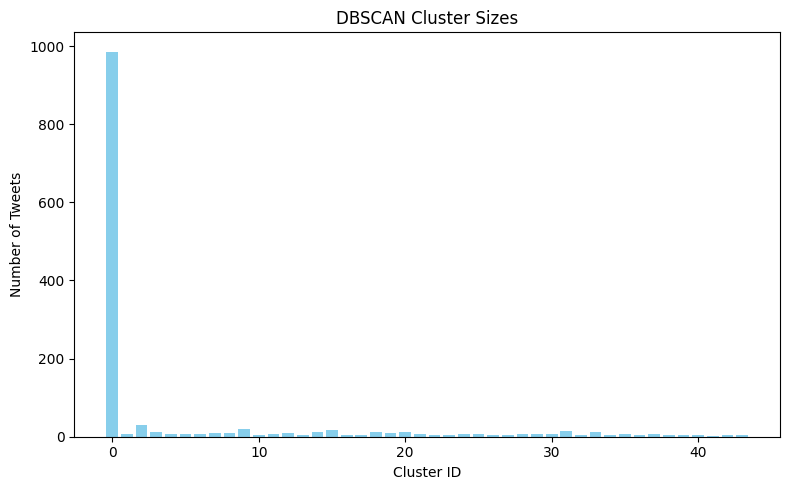

In [6]:
jaccard_dist_dbscan = 1 - jaccard_sim

#we chose eps by looking at a graph of the sorted distances and picking a value that seemed 
#to separate the lower distances from the higher ones
eps = .77

#dbscan
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
dbscan_labels = db.fit_predict(jaccard_dist_dbscan)

valid_idx_dbscan = np.where(dbscan_labels != -1)[0]
dbscan_labels_valid = dbscan_labels[valid_idx_dbscan]

# only compute if we have at least 2 clusters
dbscan_n_clusters = len(set(dbscan_labels_valid))

if dbscan_n_clusters > 1:
    sil_samples_dbscan = silhouette_samples(jaccard_dist_dbscan[valid_idx_dbscan][:, valid_idx_dbscan],
                                            dbscan_labels_valid,
                                            metric='precomputed')
    dbscan_sil = np.mean(sil_samples_dbscan)
else:
    dbscan_sil = np.nan

#overall sse
X_dense_dbscan = X.toarray()
dbscan_cluster_ids = [u for u in np.unique(dbscan_labels) if u != -1]

dbscan_sse = 0
for u in dbscan_cluster_ids:
    idx = np.where(dbscan_labels == u)[0]
    cluster_points = X_dense_dbscan[idx]
    center = cluster_points.mean(axis=0)
    dbscan_sse += np.sum((cluster_points - center) ** 2)

#overall bss
global_center_dbscan = X_dense_dbscan.mean(axis=0)

dbscan_bss = 0
for u in dbscan_cluster_ids:
    idx = np.where(dbscan_labels == u)[0]
    cluster_points = X_dense_dbscan[idx]
    cluster_center = cluster_points.mean(axis=0)
    n_k = len(idx)
    dbscan_bss += n_k * np.sum((cluster_center - global_center_dbscan) ** 2)

#print metrics
print("\nfinal metrics")
print(f"Silhouette Score: {dbscan_sil:.4f}")
print(f"SSE (Cohesion): {dbscan_sse:.4f}")
print(f"BSS (Separation): {dbscan_bss:.4f}")
print(f"Number of clusters (excluding noise): {dbscan_n_clusters}")

#cluster sizes visualization
dbscan_unique_ids = [u for u in np.unique(dbscan_labels) if u != -1]
dbscan_cluster_sizes = [(dbscan_labels == u).sum() for u in dbscan_unique_ids]

plt.figure(figsize=(8,5))
plt.bar(dbscan_unique_ids, dbscan_cluster_sizes, color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("Number of Tweets")
plt.title("DBSCAN Cluster Sizes")
plt.tight_layout()
plt.savefig("../figures/dbscan_cluster_size_distribution.png")
plt.show()

np.savetxt("dbscan_tweet_clusters.txt", dbscan_labels, fmt='%d')

### Group Average Hierarchical Clustering

The hierarchical clustering requires a choice of where the split the dendrogram to produce the final cluster assignments for the data. The number of cluster k in this analysis was first explored by search and comparison over all potential values of k, from 2 to 3,708. This search reported silhouette score as a guiding heuristic to gauge the quality of the clusterings over the search space.

In [7]:
# dist_matrix, condensed upper triangle, and dendrogram
X_dense = X.toarray()
dist_matrix = 1.0 - cos_sim
np.clip(dist_matrix, 0, None, out=dist_matrix)
condensed = squareform(dist_matrix, checks=False)
dendro = linkage(condensed, method='average')

#### Full Silhouette Search

k: 100 silhouette: 0.024043004414043695
k: 200 silhouette: 0.042697202163228316
k: 300 silhouette: 0.061876175487816834
k: 400 silhouette: 0.0778144654463316
k: 500 silhouette: 0.09311837706206343
k: 600 silhouette: 0.10761818528006994
k: 700 silhouette: 0.12320728188018183
k: 800 silhouette: 0.13497174361728032
k: 900 silhouette: 0.14987571666320054
k: 1000 silhouette: 0.15681767001570027
k: 1100 silhouette: 0.16581909238337278
k: 1200 silhouette: 0.17134648591474677
k: 1300 silhouette: 0.17325766396023753
k: 1400 silhouette: 0.17599877859205615
k: 1500 silhouette: 0.17657708528516178
k: 1600 silhouette: 0.17592435087139568
k: 1700 silhouette: 0.17667920571086324
k: 1800 silhouette: 0.1764967159923052
k: 1900 silhouette: 0.1741189423279941
k: 2000 silhouette: 0.17176937809111728
k: 2100 silhouette: 0.16718812268578814
k: 2200 silhouette: 0.16424512437113958
k: 2300 silhouette: 0.15915431777538874
k: 2400 silhouette: 0.15560046173390754
k: 2500 silhouette: 0.150004458175611
k: 2600 sil

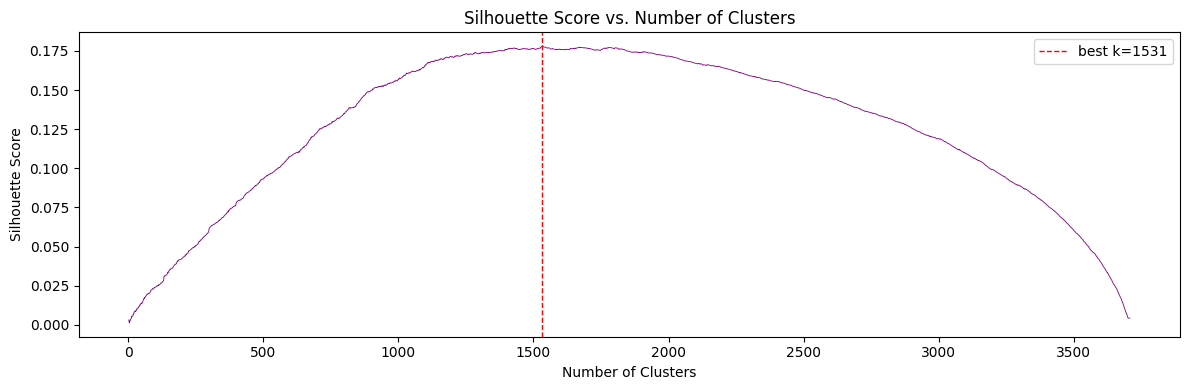

In [8]:
n_samples = dist_matrix.shape[0]
k_range = range(2, n_samples)
silhouette_scores = []

for k in k_range:
    labels_k = fcluster(dendro, k, criterion='maxclust')
    score = silhouette_score(dist_matrix, labels_k, metric='precomputed')
    silhouette_scores.append(score)
    if k % 100 == 0:
        print(f"k: {k} silhouette: {score}")

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Best k: {best_k}")

plt.figure(figsize=(12, 4))
plt.plot(list(k_range), silhouette_scores, color='purple', linewidth=0.6)
plt.axvline(best_k, color='red', linestyle='--', linewidth=1.0, label=f'best k={best_k}')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/hierarchical_silhouette.png", dpi=600)
plt.show()

Ultimately, this search produced an optimum clustering quality with a selection of k as 1,531. This clustering algorithm applied with such a selection for 3,709 tweets produces clusters so small they functionally don't represent any topical differentiation and rather differentiate by individual or small groups of shared terms within the corpus, external of any meaningful context. While producing a maximal silhouette score, we chose to pursue an additional analysis that could give a selection of k that may produce an interpretable clustering. 

For this reason, we explored use of the gap statistic for understanding how the clustering at different selections of k would compare to the clustering of random, noisy data. In this analysis, we first contrains our search from 2 to 999 as a reasonable cut-off for an ideal selection given the previous analysis. On this range, the dendrogram was cut at each value and SSE was computed.

To compared against a baseline, fifty synthetic datasets were constructed through uniform sampling within the same feature value ranges as the actual preprocessed dataset. The SSE was collected at each selection for each of these datasets as well, and the gap statistic at each k was computed as $ \text{Gap}(k) = \frac{1}{B} \sum_{b=1}^{B} \log {\text{SSE}}_k^{(b)} - \log {\text{SSE}}_k $, where B is the number of datasets. Naturally, a large gap statistic would suggest a higher quality of clustering compared to such a clustering being performed on data lacking any signal, which for this analysis would suggest that relative large gaps are more effectively identifying clustering structure within the data for their respective selections of k.

Naturally, the usage of multiple reference datasets introduces variance to the gap estimations at each k. The standard error $ s_k = \sqrt{\left(1 + \frac{1}{B}\right) \cdot \frac{1}{B} \sum_{b=1}^{B} \left(\log \text{SSE}_k^{(b)} - \overline{\log \text{SSE}_k}\right)^2} $ is utilized in imposing the Tibshirani one-standard-error rule [1] for selecting the smallest k such that the gap is within one standard error of the gap at k+1, formally as: $ k^* = \min \left\{ k : \text{Gap}(k) \geq \text{Gap}(k+1) - s_{k+1} \right\} $. This rule identifies the first case that adding another cluster does not improve the gap by more than the noise in the gap estimate, which would suggest that the addition of such a cluster is not statistically distinguishable from the improvement that would be expected from doing the same of completely randomized data.

#### Gap Statistic

observed k: 100
observed k: 200
observed k: 300
observed k: 400
observed k: 500
observed k: 600
observed k: 700
observed k: 800
observed k: 900
reference dataset 1/20
reference dataset 2/20
reference dataset 3/20
reference dataset 4/20
reference dataset 5/20
reference dataset 6/20
reference dataset 7/20
reference dataset 8/20
reference dataset 9/20
reference dataset 10/20
reference dataset 11/20
reference dataset 12/20
reference dataset 13/20
reference dataset 14/20
reference dataset 15/20
reference dataset 16/20
reference dataset 17/20
reference dataset 18/20
reference dataset 19/20
reference dataset 20/20

Optimal k: 49


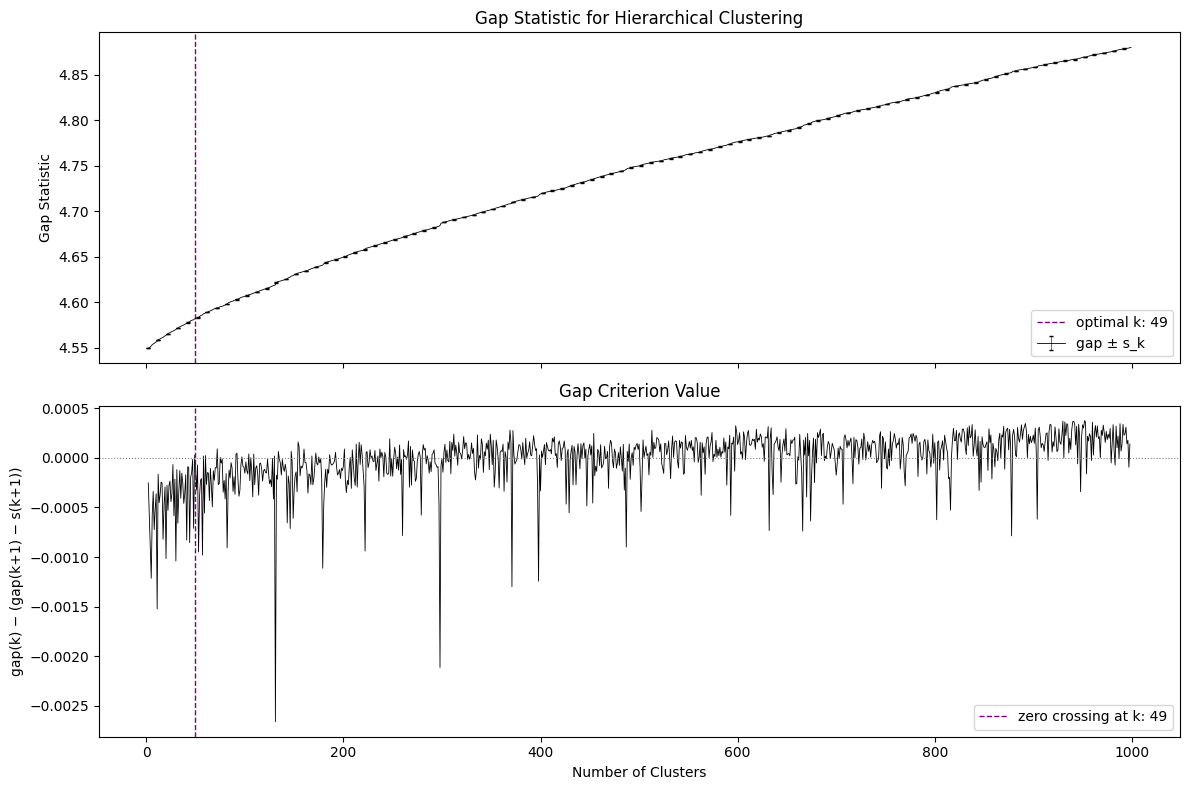

In [9]:
np.random.seed(42)
os.makedirs("../figures", exist_ok=True)

cos_sim = np.loadtxt("cosine_similarity.txt")
X = load_npz("tweet_features.npz").toarray()

dist_matrix = 1.0 - cos_sim
np.clip(dist_matrix, 0, None, out=dist_matrix)
condensed = squareform(dist_matrix, checks=False)

dendro = linkage(condensed, method='average')

def compute_wcss(X, labels):
    wcss = 0.0
    for lbl in np.unique(labels):
        cluster_points = X[labels == lbl]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)
    return wcss

k_range = range(2, 1000)
B = 20

# SSE for observed data
wcss_orig = []
for k in k_range:
    labels_k = fcluster(dendro, k, criterion='maxclust')
    wcss_orig.append(compute_wcss(X, labels_k))
    if k % 100 == 0:
        print(f"observed k: {k}")
wcss_orig = np.array(wcss_orig)

# SSE for reference datasets
wcss_refs = np.zeros((len(k_range), B))
mins = X.min(axis=0)
maxs = X.max(axis=0)

for b in range(B):
    X_ref = np.random.uniform(low=mins, high=maxs, size=X.shape)
    cos_sim_ref = cosine_similarity(X_ref)
    dist_ref = 1.0 - cos_sim_ref
    np.clip(dist_ref, 0, None, out=dist_ref)
    condensed_ref = squareform(dist_ref, checks=False)
    dendro_ref = linkage(condensed_ref, method='average')
    for i, k in enumerate(k_range):
        labels_ref = fcluster(dendro_ref, k, criterion='maxclust')
        wcss_refs[i, b] = compute_wcss(X_ref, labels_ref)
    print(f"reference dataset {b + 1}/{B}")

# gap statistic and standard error
log_wcss_ref = np.log(wcss_refs).mean(axis=1)
gap = log_wcss_ref - np.log(wcss_orig)
s_k = np.sqrt(((np.log(wcss_refs) - log_wcss_ref[:, None]) ** 2).sum(axis=1) / B) * np.sqrt(1 + 1 / B)

criterion = gap[:-1] - (gap[1:] - s_k[1:])

opt_k = None
for i in range(len(criterion)):
    if criterion[i] >= 0:
        opt_k = list(k_range)[i]
        break

# Falls back to argmax if hte gap criterion doesn't trigger within k range
if opt_k is None:
    opt_k = list(k_range)[np.argmax(gap)]

print(f"\nOptimal k: {opt_k}")
k_vals = list(k_range)[:-1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gap statistic
axes[0].errorbar(list(k_range), gap, yerr=s_k, fmt='-', color='black',
                 linewidth=0.6, elinewidth=0.4, capsize=1.5,
                 errorevery=10, label='gap ± s_k')
axes[0].axvline(opt_k, color='purple', linestyle='--', linewidth=1.0,
                label=f'optimal k: {opt_k}')
axes[0].set_ylabel("Gap Statistic")
axes[0].set_title("Gap Statistic for Hierarchical Clustering")
axes[0].legend()

# Criterion value
axes[1].plot(k_vals, criterion, color='black', linewidth=0.6)
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].axvline(opt_k, color='purple', linestyle='--', linewidth=1.0,
                label=f'zero crossing at k: {opt_k}')
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("gap(k) − (gap(k+1) − s(k+1))")
axes[1].set_title("Gap Criterion Value")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/hier_gap_stat.png", dpi=600)
plt.show()

The gap statistic analysis identified k=49 as the optimal selection for this clustering. Similar to the results we saw in the previous analysis, the clustering structure in this feature space is not very strong and so the gap statistic increases monotonically over the search. However, the bottom panel shows a rapid oscillation through the search range, with a slight global overall increase, identifying k=49 as the first point at which the increase in gap did not exceed one standard error of the next k selection's gap. That being said, this oscillation indicates a rather weak clustering structure within the real data because the gap differences between adjacent k selections are so small that they are frequently exceeded by the variance introduced by the reference datasets.

However, the steady increase globally for the gap statistic confirms that topical clustering structure is at least detectable within the corpus as the real clustering consistently outperforms the random data, but the strucutre itself, as the previous analysis suggests, is distributed across many small groups of tweets sharing a small number of terms rather than being concentrated within a small number of large clusters.

#### Group Average Hierarchical Clustering Algorithm

The hierarchical clustering was carried out for k=49, using maximum group average similarity at each merging step. Group average was selected primarily due to how short tweets typically are and therefore how little the shared term overlap can be for a given pair of tweets. Using strategies such as single-link for example produce merges where one tweet in a cluster may share many terms with the most similiar tweet within another cluster, however many of the other cluster's consituents could share little to no terms with the original tweet, producing a new cluster that has very little cohesion. Likewise, using complete-link proves to be a challenge of finding merges that maintain separation without merging on pairs that have nearly zero similarity. In a feature space so sparse and with little to no overlap between tweets being fairly abundant, this clustering strategy fails to produce distinct clusters of tweets entirely. The group average clustering strategy addresses this issue precisely because it dilutes the influence of very similar or dissimilar tweets within a given cluster, which is a much more effective representation of a cluster for the purpose of merging within this sparse and high dimensional of a feature space.

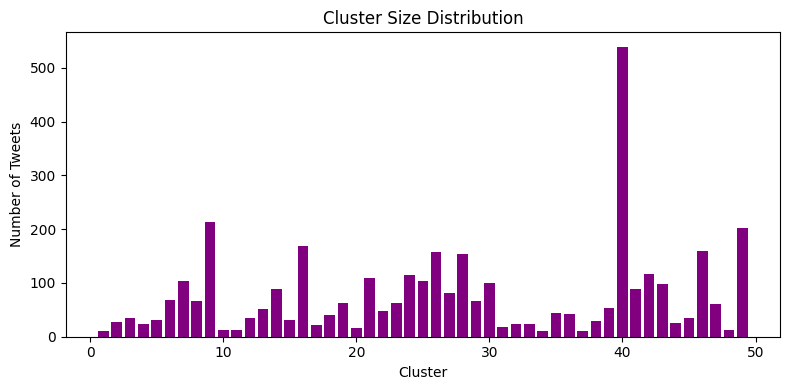

Clusters: 49

SSE: 3522.621235273825
BSS: 169.18974738803124
Silhouette Score: 0.013966573021542975


In [10]:
labels = fcluster(dendro, 49, criterion='maxclust')
np.savetxt("hierarchical_tweet_clusters.txt", labels, fmt="%d")
 
unique_clusters, counts = np.unique(labels, return_counts=True)
 
plt.figure(figsize=(8, 4))
plt.bar(unique_clusters, counts, color='purple', edgecolor='none')
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.savefig("../figures/hierarchical_cluster_size_distribution.png", dpi=600)
plt.show()
 
global_centroid = X.mean(axis=0)
sse, bss = 0.0, 0.0
for c in unique_clusters:
    members = X[labels == c]
    centroid = members.mean(axis=0)
    sse += np.sum((members - centroid) ** 2)
    bss += len(members) * np.sum((centroid - global_centroid) ** 2)

sil = silhouette_score(dist_matrix, labels, metric='precomputed')
 
print(f"Clusters: {len(unique_clusters)}")
print(f"\nSSE: {sse}")
print(f"BSS: {bss}")
print(f"Silhouette Score: {sil}")

hier_unique_clusters = unique_clusters
hier_counts = counts
hier_sse = sse
hier_bss = bss
hier_sil = sil

The group average hierarchical clustering distribution exhibits a handful of larger dominant clusters in the data alongside many small clusters containing less than 100 tweets. The SSE of 3,522.62 and BSS of 169.19 indicate that the degree of separation between clusters is far exceeded by the variance within the clusters. The silhouette score of 0.014 corroborates that the cluster boundaries are not well-defined in the cosine similarity space for this algorithm, which is consistent with the previous analyses highlighting that the tweets do not exhibit a strong clustering structure within this feature space.

### Shared Nearest Neighbor Clustering
The shared nearest neighbor clustering was done using density-based clustering following the construction of the shared nearest neighbor (SNN) graph. A tweet is designated as a core point for having at least some number of neighbors with Jaccard similarity at or above a given threshold. The use of density-based, or DBSCAN, style clustering together with the construction of the SNN graph requires selecting an appropriate neighborhood size $ k $, the minimum number of neighbors for two points to be considered connected $ eps $, and the minimum number of such qualifying connections for a tweet to be considered a core point, $ min\_pts $.

The most effective analysis found for these selections was a joint parameter search using a composite score as a guiding heuristic. Utilizing density based clustering on this graph structure opens the possibility that some number of tweets are discarded from the clustering as noise points, and for this reason, using just a simple statistic like silhouette poses a concern that such a search will find solutions that identify the overwhelming majority of tweets as noise given the sparsity and weak clustering structure of this data. The composite score used for the search is then the respective silhouette score weighted by the proportion of the data that was not discarded as noise $ \text{composite} = \text{silhouette} \times \frac{|\text{assigned tweets}|}{n} $. The search ranges for each hyperparameter were as follows: $ k \in \{2,...,15\}, eps \in \{2,...,7\}, min\_pts \in \{2,3,4,5\} $. Exceeding beyond these ranges showed degenerate solutions for varying reasons given this feature space. First, a selection of neighborhoods too large caused the SNN graph to be very densely connected, which would in turn cluster most tweets into a single grouping regardless of the selections of $ eps $ or $ min\_pts $. Constraining the selection of $ k $ to below 15 then meant that the selection of $ eps $ could not be too strict so as to from one large cluster due to no valid breaking points within the graph being identified. The selection of $ min\_pts $ likewise needed to be amenable to forming core points within this feature space, meaning that a threshold set too high would otherwise label the overwhelming majority of tweets as noise, forming no meaningful clustering.

k: 2 eps: 2, min_pts: 2   clusters: 63 noise: 3432 sil: 0.1148939305708236 coverage=0.07468320301968186 composite: 0.00858064674255005
k: 2 eps: 2, min_pts: 3   clusters: 39 noise: 3504 sil: 0.1388930583789935 coverage=0.05527096252359127 composite: 0.0076767530244523235
k: 2 eps: 2, min_pts: 4   clusters: 22 noise: 3572 sil: 0.1468482595877336 coverage=0.03693717983283904 composite: 0.0054241605725315455
k: 2 eps: 2, min_pts: 5   clusters: 13 noise: 3617 sil: 0.1530793040017691 coverage=0.02480452952278242 composite: 0.003797060115438867
k: 2 eps: 3 min_pts: 2   clusters: 0 skipped
k: 2 eps: 3 min_pts: 3   clusters: 0 skipped
k: 2 eps: 3 min_pts: 4   clusters: 0 skipped
k: 2 eps: 3 min_pts: 5   clusters: 0 skipped
k: 2 eps: 4 min_pts: 2   clusters: 0 skipped
k: 2 eps: 4 min_pts: 3   clusters: 0 skipped
k: 2 eps: 4 min_pts: 4   clusters: 0 skipped
k: 2 eps: 4 min_pts: 5   clusters: 0 skipped
k: 2 eps: 5 min_pts: 2   clusters: 0 skipped
k: 2 eps: 5 min_pts: 3   clusters: 0 skipped
k: 2 

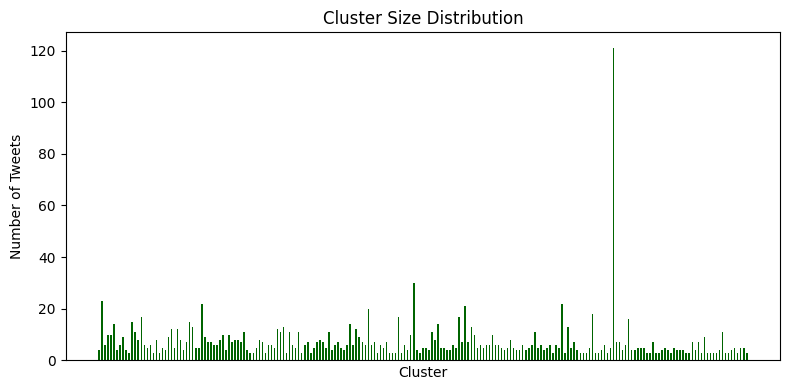


SSE: 984.2499954787964
BSS: 571.3990451849655
Silhouette Score: 0.12586257502951595


In [11]:
n = jaccard_sim.shape[0]
dist = 1.0 - jaccard_sim

def build_snn_matrix(sim_matrix, k):
    A = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        row = sim_matrix[i].copy()
        row[i] = -1  # excludes self
        top_k = np.argsort(row)[::-1][:k]
        A[i, top_k] = 1.0
    snn = (A @ A.T).astype(np.float32)
    np.fill_diagonal(snn, 0)
    return snn

def run_snn_clustering(snn_sim, eps, min_pts):
    labels = np.full(n, -1, dtype=int)
    core_points = set(np.where((snn_sim >= eps).sum(axis=1) >= min_pts)[0])

    cluster_id = 0
    visited = set()

    for core_point in core_points:
        if core_point in visited:
            continue
        queue = deque([core_point])
        visited.add(core_point)
        while queue:
            p = queue.popleft()
            labels[p] = cluster_id
            if p in core_points:
                neighbors = np.where(snn_sim[p] >= eps)[0]
                for nb in neighbors:
                    if nb not in visited:
                        visited.add(nb)
                        queue.append(nb)
        cluster_id += 1

    return labels

# Joint search over the hyperparameters
k_values = list(range(2, 16))
eps_values = list(range(2, 8))
min_pts_values = [2, 3, 4, 5]

best_score = -np.inf
best_params = None
best_labels = None

for k in k_values:
    snn_sim = build_snn_matrix(jaccard_sim, k)
    for eps in eps_values:
        for min_pts in min_pts_values:
            labels_try = run_snn_clustering(snn_sim, eps, min_pts)
            n_clusters = len(set(labels_try[labels_try != -1]))
            n_noise = int((labels_try == -1).sum())
            valid = labels_try != -1

            if n_clusters < 2 or valid.sum() < 2:
                print(f"k: {k} eps: {eps} min_pts: {min_pts}   clusters: {n_clusters} skipped")
                continue

            sil = silhouette_score(dist[np.ix_(valid, valid)], labels_try[valid], metric='precomputed')
            coverage = valid.sum() / n
            composite = sil * coverage

            print(f"k: {k} eps: {eps}, min_pts: {min_pts}   clusters: {n_clusters} noise: {n_noise} sil: {sil} coverage={coverage} composite: {composite}")

            if composite > best_score:
                best_score = composite
                best_params = (k, eps, min_pts)
                best_labels = labels_try.copy()

best_k, best_eps, best_min_pts = best_params
print(f"\nOptimal params\n k: {best_k} eps: {best_eps} min_pts: {best_min_pts}")
np.savetxt("snn_tweet_clusters.txt", best_labels, fmt="%d")

unique_clusters = np.unique(best_labels[best_labels != -1])
counts = [(best_labels == c).sum() for c in unique_clusters]
n_noise = int((best_labels == -1).sum())

print(f"clusters: {len(unique_clusters)}, noise: {n_noise} ({100 * n_noise / n:.1f}%)")
for c, cnt in zip(unique_clusters, counts):
    print(f"cluster {c}: {cnt} tweets")

plt.figure(figsize=(8, 4))
plt.bar(unique_clusters, counts, width=0.5, color='darkgreen', edgecolor='none')
plt.xticks([])
plt.title(f"Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.savefig("../figures/snn_cluster_size_distribution.png", dpi=600)
plt.show()

# Cohesion, separation, silhouette
valid_mask = best_labels != -1
X_valid = X[valid_mask]
labels_valid = best_labels[valid_mask]
global_centroid = X_valid.mean(axis=0)

sse, bss = 0.0, 0.0
for c in unique_clusters:
    members = X_valid[labels_valid == c]
    centroid = members.mean(axis=0)
    sse += np.sum((members - centroid) ** 2)
    bss += len(members) * np.sum((centroid - global_centroid) ** 2)

sil = silhouette_score(dist[np.ix_(valid_mask, valid_mask)], labels_valid, metric='precomputed')

print(f"\nSSE: {sse}")
print(f"BSS: {bss}")
print(f"Silhouette Score: {sil}")

snn_sse = sse
snn_bss = bss
snn_sil = sil

The joint search identified the following optimal hyperparameters: $ k = 5, eps = 3, min\_pts = 2$. The SNN clustering was carried out for these selections, which produced 215 clusters and identifying 57.8% of the tweets as noise. This clustering reported an SSE of 984.25, BSS of 571.40, and a silhouette score of 0.13, reflecting a much stronger clustering result relative to the hierarchical clustering. The improvement in the ratio of the SSE to the BSS indicates for this approach that a meaningful proportion of the toal variance is explained by the clustering structure, which is corroborated by the higher silhouette score. The high proportion of noise as well supports the previous analyses that highlighted how weak the natural clustering strucutre of the data is, with many tweets under this representation being too dissimilar to the rest of the documents to exhibit any meaningful term overlap.

## Results

### Number of Clusters and Cluster Size Distributions

### Spherical K-Means

In [12]:
print(f"Spherical K-Means: {len(kmeans_unique)} clusters")
for u, c in zip(kmeans_unique, kmeans_counts):
    print(f"  Cluster {u}: {c} tweets")

Spherical K-Means: 9 clusters
  Cluster 0: 2632 tweets
  Cluster 1: 92 tweets
  Cluster 2: 101 tweets
  Cluster 3: 156 tweets
  Cluster 4: 105 tweets
  Cluster 5: 132 tweets
  Cluster 6: 151 tweets
  Cluster 7: 209 tweets
  Cluster 8: 131 tweets


### DBSCAN

In [13]:
dbscan_n_noise = int((dbscan_labels == -1).sum())
print(f"DBSCAN: {dbscan_n_clusters} clusters, {dbscan_n_noise} noise points ({100 * dbscan_n_noise / len(dbscan_labels):.1f}%)")
for u, c in zip(dbscan_unique_ids, dbscan_cluster_sizes):
    print(f"  Cluster {u}: {c} tweets")

DBSCAN: 44 clusters, 2377 noise points (64.1%)
  Cluster 0: 986 tweets
  Cluster 1: 8 tweets
  Cluster 2: 29 tweets
  Cluster 3: 11 tweets
  Cluster 4: 6 tweets
  Cluster 5: 8 tweets
  Cluster 6: 7 tweets
  Cluster 7: 9 tweets
  Cluster 8: 9 tweets
  Cluster 9: 20 tweets
  Cluster 10: 4 tweets
  Cluster 11: 8 tweets
  Cluster 12: 10 tweets
  Cluster 13: 5 tweets
  Cluster 14: 11 tweets
  Cluster 15: 18 tweets
  Cluster 16: 4 tweets
  Cluster 17: 5 tweets
  Cluster 18: 11 tweets
  Cluster 19: 9 tweets
  Cluster 20: 13 tweets
  Cluster 21: 8 tweets
  Cluster 22: 5 tweets
  Cluster 23: 5 tweets
  Cluster 24: 6 tweets
  Cluster 25: 7 tweets
  Cluster 26: 4 tweets
  Cluster 27: 5 tweets
  Cluster 28: 7 tweets
  Cluster 29: 6 tweets
  Cluster 30: 6 tweets
  Cluster 31: 14 tweets
  Cluster 32: 4 tweets
  Cluster 33: 11 tweets
  Cluster 34: 5 tweets
  Cluster 35: 8 tweets
  Cluster 36: 5 tweets
  Cluster 37: 7 tweets
  Cluster 38: 5 tweets
  Cluster 39: 5 tweets
  Cluster 40: 5 tweets
  Cluste

### Group Average Hierarchical Clustering

In [14]:
print(f"Group Average Hierarchical Clustering: {len(hier_unique_clusters)} clusters")
for c, cnt in zip(hier_unique_clusters, hier_counts):
    print(f"cluster {c}: {cnt} tweets")

Group Average Hierarchical Clustering: 49 clusters
cluster 1: 10 tweets
cluster 2: 27 tweets
cluster 3: 34 tweets
cluster 4: 24 tweets
cluster 5: 31 tweets
cluster 6: 69 tweets
cluster 7: 103 tweets
cluster 8: 67 tweets
cluster 9: 213 tweets
cluster 10: 12 tweets
cluster 11: 13 tweets
cluster 12: 35 tweets
cluster 13: 51 tweets
cluster 14: 88 tweets
cluster 15: 32 tweets
cluster 16: 169 tweets
cluster 17: 21 tweets
cluster 18: 41 tweets
cluster 19: 63 tweets
cluster 20: 16 tweets
cluster 21: 109 tweets
cluster 22: 48 tweets
cluster 23: 63 tweets
cluster 24: 114 tweets
cluster 25: 104 tweets
cluster 26: 158 tweets
cluster 27: 81 tweets
cluster 28: 153 tweets
cluster 29: 67 tweets
cluster 30: 100 tweets
cluster 31: 18 tweets
cluster 32: 23 tweets
cluster 33: 23 tweets
cluster 34: 11 tweets
cluster 35: 45 tweets
cluster 36: 42 tweets
cluster 37: 11 tweets
cluster 38: 29 tweets
cluster 39: 53 tweets
cluster 40: 539 tweets
cluster 41: 89 tweets
cluster 42: 116 tweets
cluster 43: 98 tweets
c

### Shared Nearest Neighbor

In [15]:
print(f"SNN: {len(unique_clusters)} clusters, {n_noise} noise points ({100 * n_noise / n:.1f}%)")
for c, cnt in zip(unique_clusters, counts):
    print(f"cluster {c}: {cnt} tweets")

SNN: 215 clusters, 2142 noise points (57.8%)
cluster 0: 4 tweets
cluster 1: 23 tweets
cluster 2: 6 tweets
cluster 3: 10 tweets
cluster 4: 10 tweets
cluster 5: 14 tweets
cluster 6: 4 tweets
cluster 7: 6 tweets
cluster 8: 9 tweets
cluster 9: 4 tweets
cluster 10: 3 tweets
cluster 11: 15 tweets
cluster 12: 11 tweets
cluster 13: 8 tweets
cluster 14: 17 tweets
cluster 15: 6 tweets
cluster 16: 5 tweets
cluster 17: 6 tweets
cluster 18: 3 tweets
cluster 19: 8 tweets
cluster 20: 3 tweets
cluster 21: 5 tweets
cluster 22: 4 tweets
cluster 23: 9 tweets
cluster 24: 12 tweets
cluster 25: 5 tweets
cluster 26: 12 tweets
cluster 27: 8 tweets
cluster 28: 4 tweets
cluster 29: 7 tweets
cluster 30: 15 tweets
cluster 31: 13 tweets
cluster 32: 5 tweets
cluster 33: 5 tweets
cluster 34: 22 tweets
cluster 35: 9 tweets
cluster 36: 7 tweets
cluster 37: 7 tweets
cluster 38: 6 tweets
cluster 39: 6 tweets
cluster 40: 8 tweets
cluster 41: 10 tweets
cluster 42: 4 tweets
cluster 43: 10 tweets
cluster 44: 7 tweets
cluste

### Cohesion, Separation, and Silhouette Score


In [16]:
print(f"{'Method':<30} {'SSE':>12} {'BSS':>12} {'Silhouette':>12}")
print(f"{'Spherical K-Means':<30} {kmeans_sse:>12.4f} {kmeans_bss:>12.4f} {kmeans_sil:>12.4f}")
print(f"{'DBSCAN':<30} {dbscan_sse:>12.4f} {dbscan_bss:>12.4f} {dbscan_sil:>12.4f}")
print(f"{'Group Average Hierarchical':<30} {hier_sse:>12.4f} {hier_bss:>12.4f} {hier_sil:>12.4f}")
print(f"{'Shared Nearest Neighbor':<30} {snn_sse:>12.4f} {snn_bss:>12.4f} {snn_sil:>12.4f}")

Method                                  SSE          BSS   Silhouette
Spherical K-Means                 3586.4181     105.3929       0.0209
DBSCAN                            1199.0636     122.6373       0.0088
Group Average Hierarchical        3522.6212     169.1897       0.0140
Shared Nearest Neighbor            984.2500     571.3990       0.1259


### Entropy and Purity

We selected the hierarchical clustering and the SNN clustering to evaluate for consistency between their assignments. The hierarchical approach is used as the reference labeling because by construction it assigns every tweet to a cluster, so it's guaranteed to provide a complete reference for the assignments that the SNN algorithm did produce.

In [17]:
def compute_entropy_purity(predicted_labels, reference_labels):
    # Excludes noise points
    valid = predicted_labels != -1
    pred = predicted_labels[valid]
    ref = reference_labels[valid]
    n = len(pred)

    clusters = np.unique(pred)
    entropy_total = 0.0
    purity_total = 0.0

    for c in clusters:
        mask = pred == c
        cluster_size = mask.sum()
        ref_in_cluster = ref[mask]
        _, ref_counts = np.unique(ref_in_cluster, return_counts=True)
        probs = ref_counts / cluster_size
        entropy_total += (cluster_size / n) * (-np.sum(probs * np.log2(probs + 1e-10)))
        purity_total += ref_counts.max() / n

    return entropy_total, purity_total

avg_labels_ep = np.loadtxt("hierarchical_tweet_clusters.txt", dtype=int)
snn_labels_ep = np.loadtxt("snn_tweet_clusters.txt", dtype=int)

entropy, purity = compute_entropy_purity(snn_labels_ep, avg_labels_ep)
print(f"Entropy: {entropy}")
print(f"Purity:  {purity}")

Entropy: 0.9684789883699837
Purity:  0.7511167836630505


75% of the tweets in each SNN cluster belong to the same cluster as the reference labeling, so the two approaches demonstrate a fair degree of alignment. The entropy of 0.9685 corroborates this result, indicating that there exists some variation within the SNN clusters relative to the labeling of the hierarchical algorithm. However, the extent is mild, and coupled with the purity of 0.75, the clusterings are not identical but they do overlap in their assignments and likely contain comparable topical structure.

### Heatmap Visualizations

#### Spherical K-Means Heatmap

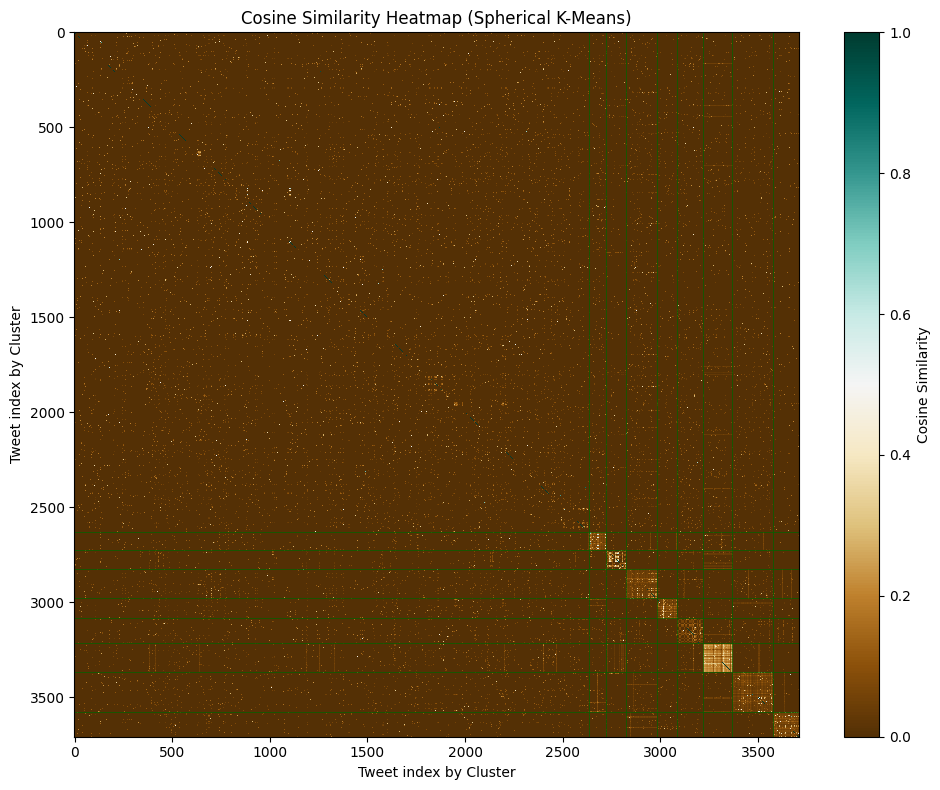

In [18]:
sorted_idx_kmeans = np.argsort(kmeans_labels)
reordered_kmeans = cos_sim[np.ix_(sorted_idx_kmeans, sorted_idx_kmeans)]
sorted_kmeans_labels = kmeans_labels[sorted_idx_kmeans]

plt.figure(figsize=(10, 8))
plt.imshow(reordered_kmeans, aspect='auto', cmap='BrBG', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title("Cosine Similarity Heatmap (Spherical K-Means)")
plt.xlabel("Tweet index by Cluster")
plt.ylabel("Tweet index by Cluster")

boundary = 0
for c in kmeans_unique[:-1]:
    boundary += (sorted_kmeans_labels == c).sum()
    plt.axhline(boundary - 0.5, color='darkgreen', linewidth=0.5)
    plt.axvline(boundary - 0.5, color='darkgreen', linewidth=0.5)

plt.tight_layout()
plt.savefig("../figures/kmeans_heatmap.png", dpi=150)
plt.show()

#### DBSCAN Heatmap

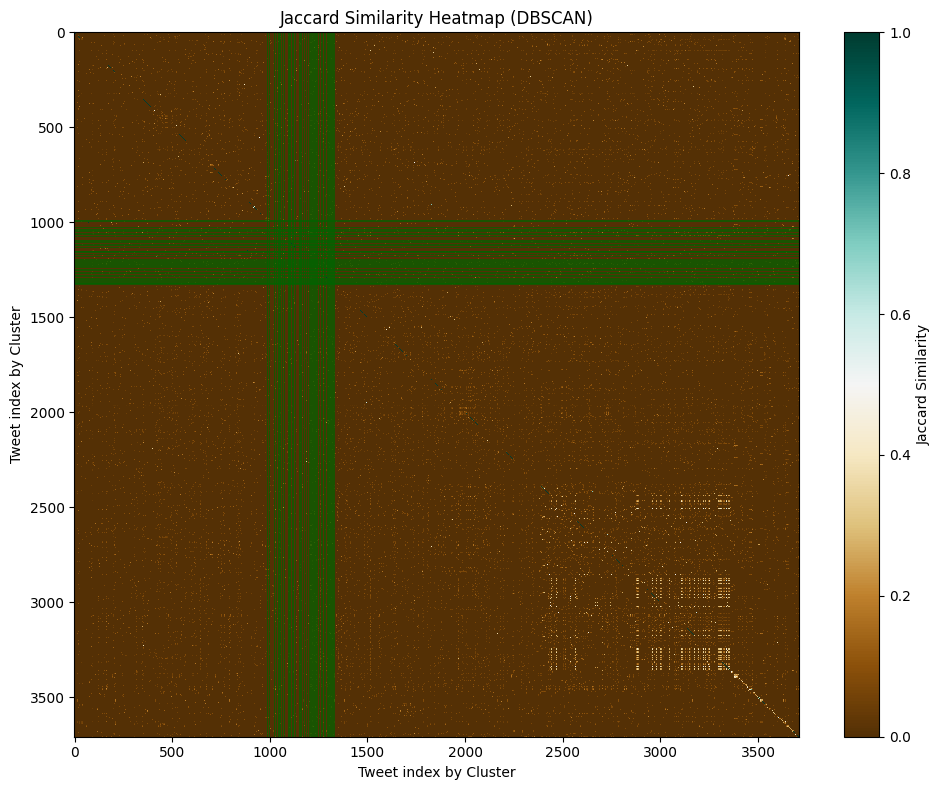

In [19]:
sorted_idx_dbscan = np.argsort(dbscan_labels)
reordered_dbscan = jaccard_sim[np.ix_(sorted_idx_dbscan, sorted_idx_dbscan)]
sorted_dbscan_labels = dbscan_labels[sorted_idx_dbscan]

plt.figure(figsize=(10, 8))
plt.imshow(reordered_dbscan, aspect='auto', cmap='BrBG', interpolation='nearest')
plt.colorbar(label='Jaccard Similarity')
plt.title("Jaccard Similarity Heatmap (DBSCAN)")
plt.xlabel("Tweet index by Cluster")
plt.ylabel("Tweet index by Cluster")

dbscan_boundary = 0
for c in dbscan_unique_ids[:-1]:
    dbscan_boundary += (sorted_dbscan_labels == c).sum()
    plt.axhline(dbscan_boundary - 0.5, color='darkgreen', linewidth=0.5)
    plt.axvline(dbscan_boundary - 0.5, color='darkgreen', linewidth=0.5)

plt.tight_layout()
plt.savefig("../figures/dbscan_heatmap.png", dpi=150)
plt.show()

#### Group Average Hierarchical Clustering Heatmap

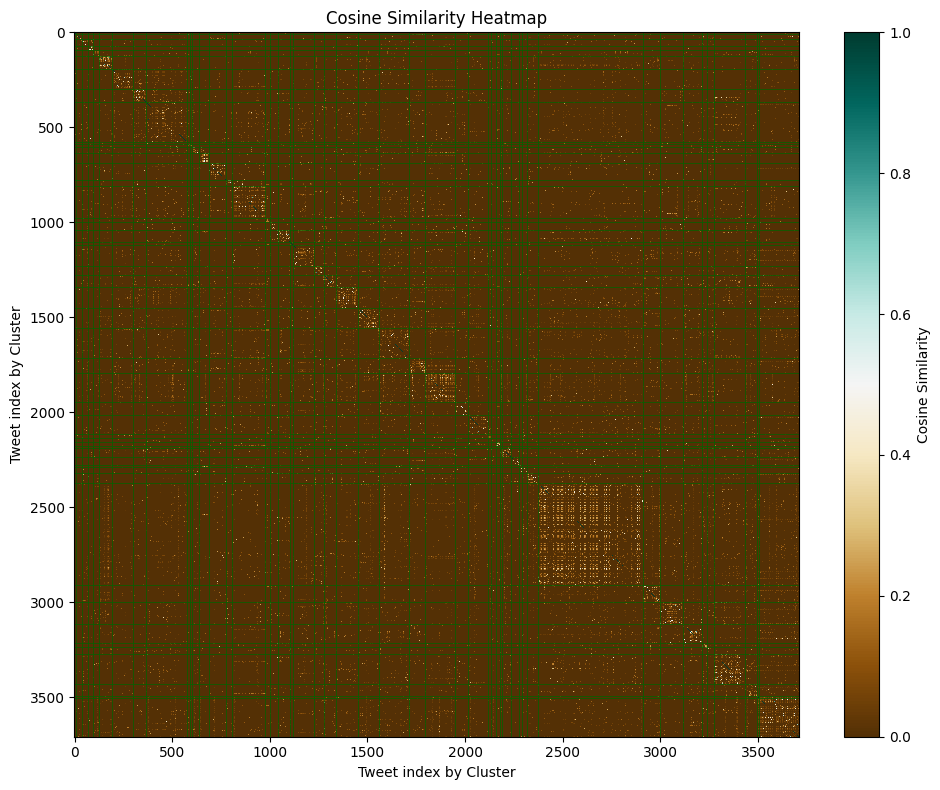

In [20]:
order = np.argsort(labels)
reordered = cos_sim[np.ix_(order, order)]
sorted_labels = labels[order]

plt.figure(figsize=(10, 8))
plt.imshow(reordered, aspect='auto', cmap='BrBG', interpolation='nearest')
plt.colorbar(label='Cosine Similarity')
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Tweet index by Cluster")
plt.ylabel("Tweet index by Cluster")

# Cluster boundaries
boundary = 0
for c in unique_clusters[:-1]:
    boundary += (sorted_labels == c).sum()
    plt.axhline(boundary - 0.5, color='darkgreen', linewidth=0.5)
    plt.axvline(boundary - 0.5, color='darkgreen', linewidth=0.5)

plt.tight_layout()
plt.savefig("../figures/hierarchical_heatmap.png", dpi=150)
plt.show()

The clusters produced by the hierarchical clustering are visible along the diagonal but do reflect the weak cohesion identified by the SSE and silhouette score statistics in how faint and non-concentrated they are within their boundary lines. The largest bright block corresponds to cluster 40 from the cluster size distribution, which contained 539 tweets and possessed higher internal similarity then the other clusters, suggesting that it captured a cohesive topical group within the dataset. The darker off-diagonal regions within the heatmap suggest that while the separation was not exceptional, the tweets within clusters are at least more similar to their respective constituents than to those outside of their cluster.

#### Shared Nearest Neighbor Heatmap

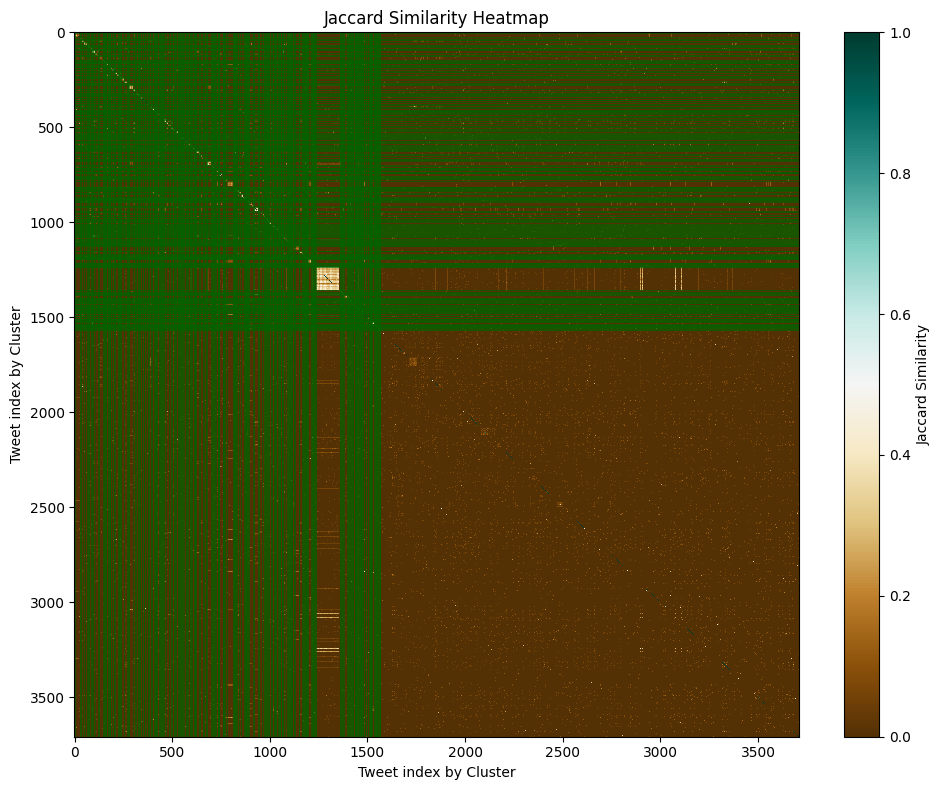

In [21]:
labels = np.loadtxt("snn_tweet_clusters.txt", dtype=int)

cluster_order = np.argsort(labels[labels != -1])
clustered_indices = np.where(labels != -1)[0][cluster_order]
noise_indices = np.where(labels == -1)[0]
order = np.concatenate([clustered_indices, noise_indices])

reordered = jaccard_sim[np.ix_(order, order)]
sorted_labels = labels[order]

plt.figure(figsize=(10, 8))
plt.imshow(reordered, aspect='auto', cmap='BrBG', interpolation='nearest')
plt.colorbar(label='Jaccard Similarity')
plt.title("Jaccard Similarity Heatmap")
plt.xlabel("Tweet index by Cluster")
plt.ylabel("Tweet index by Cluster")

boundary = 0
for c in unique_clusters[:-1]:
    boundary += (sorted_labels == c).sum()
    plt.axhline(boundary - 0.5, color='darkgreen', linewidth=0.5)
    plt.axvline(boundary - 0.5, color='darkgreen', linewidth=0.5)

# Noise boundary line
n_clustered = (labels != -1).sum()
plt.axhline(n_clustered - 0.5, color='darkgreen', linewidth=0.5)
plt.axvline(n_clustered - 0.5, color='darkgreen', linewidth=0.5)

plt.tight_layout()
plt.savefig("../figures/snn_heatmap.png", dpi=150)
plt.show()

The upper left region of the heatmap contains the 215 clusters and shows a clear set of diagonal blocks with noticeably higher concentration within each cluster than the off-diagonal regions, which reflects the separation and cohesion statistics for this algorithm well. One cluster stands out within this algorithm as well for its very large proportion of tweets a high cohesion, grouping 121 tweets from the dataset.

The lower right region beyond the cluster boundaries represents the data points identified as noise during the density-based clustering, and the dark, uniform coloring suggests that the overwhelming majority of these points share very little similarity with any other tweets. There is a very limited number of noisy tweets within the clustering that appear to share a noticeable degree of similarity within the dominant cluster represented by the brighter beams adjacent to the dominant cluster block, however the clustering overall does well to isolate the topical groups from the majority of tweets that lack a sufficient number of shared terms to indicate any similarity.

#### Top 10 Commonly Used Words in a Prominent Cluster

In [22]:
print(f"Top 10 words in largest Spherical K-Means cluster (Cluster {largest_cluster_kmeans}, {len(cluster_idx_kmeans)} tweets):")
print(top_words_kmeans.to_string(index=False))

Top 10 words in largest Spherical K-Means cluster (Cluster 0, 2632 tweets):
   word     score
   kids 28.249909
   says 25.604385
  brain 22.373933
    amp 19.970412
   help 19.424162
healthy 19.319577
    flu 17.122751
   make 16.226273
   food 16.142512
medical 14.762608
